In [7]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import h5py
from collections import Counter
from itertools import combinations

import scipy.sparse as sp
from matplotlib.patches import Patch
import yaml
import time
import gget

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

import scvi
from scvi.external import SysVI

import cupy as cp
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

from cuml.manifold.umap import simplicial_set_embedding
from scanpy.tools._utils import get_init_pos_from_paga 
from cuml.manifold.umap import find_ab_params

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 3

In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/isoforms.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 210 ms, sys: 458 ms, total: 668 ms
Wall time: 2.76 s


AnnData object with n_obs × n_vars = 21062 × 113335
    obs: 'dataset', 'dataset_bdata', 'source', 'cluster', 'group', 'label', 'filter_pass', 'bm_clusters', 'subgroup'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id'
    uns: 'subgroup_colors'
    obsm: 'X_umap'

In [3]:
# summarize number of isoforms per cluster
transcript_read_threshold = 10 # minimum number of counts per cluster

results = []

for group_name, group in adata.obs.groupby('subgroup', observed=True):
    tmp = adata[group.index, :].copy()
    var = tmp.var.copy()

    # get the transcripts
    var['reads_per_transcript'] = np.ravel(tmp.X.sum(axis=0))
    var = var[var['gene_type'] == 'protein_coding']
    var = var[var['transcript_type'] == 'protein_coding']
    var['transcript_pass'] = var['reads_per_transcript'] > transcript_read_threshold
    
    var = var.groupby('gene_name')['transcript_pass'].sum()
    var = var.map(lambda x: "NE" if x == 0 else "single" if x == 1 else "multi")
    var.name = group_name
    results.append(var)

# save sankey inputs
outpath = "/scratch/indikar_root/indikar1/shared_data/for_joshua/sankey_inputs.csv"
results = pd.concat(results, axis=1)
results = results.reset_index()
results.to_csv(outpath, index=False)
results.head()

,gene_name,C1,C2,C3,CLP,HSC,LMPP,intial,progenitors
0,A1BG,NE,NE,NE,NE,NE,NE,NE,NE
1,A1BG-AS1,NE,NE,NE,NE,NE,NE,NE,NE
2,A2M,single,single,single,NE,NE,NE,single,NE
3,A2M-AS1,NE,NE,NE,NE,NE,NE,NE,NE
4,A2ML1,NE,NE,NE,NE,single,single,NE,single


In [6]:
results.columns

Index(['gene_name', 'C1', 'C2', 'C3', 'CLP', 'HSC', 'LMPP', 'intial',
       'progenitors'],
      dtype='object')

In [5]:
print(results.head().to_string())

  gene_name      C1      C2      C3 CLP     HSC    LMPP  intial progenitors
0      A1BG      NE      NE      NE  NE      NE      NE      NE          NE
1  A1BG-AS1      NE      NE      NE  NE      NE      NE      NE          NE
2       A2M  single  single  single  NE      NE      NE  single          NE
3   A2M-AS1      NE      NE      NE  NE      NE      NE      NE          NE
4     A2ML1      NE      NE      NE  NE  single  single      NE      single


In [66]:
# your categorical columns
cols = ['C2','C3','HSC','intial','progenitors']

# collect results in a list of dicts
summary = []
for c1, c2 in combinations(cols, 2):
    # matrix of counts for each (type in c1) × (type in c2)
    ct = (
        pd.crosstab(results[c1], results[c2])
          .reindex(index=['NE','single','multi'],
                   columns=['NE','single','multi'],
                   fill_value=0)
    )
    # shared = diagonal entries
    shared = {t: int(ct.at[t, t]) for t in ct.index}
    # all genes in this pair
    total = int(ct.values.sum())
    # different = total minus sum(shared)
    different = total - sum(shared.values())
    summary.append({
        'pair': f'{c1}/{c2}',
        **{f'{t}': shared[t] for t in shared},
        'diff': different
    })

# put into a DataFrame for easy viewing
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

              pair    NE  single  multi  diff
             C2/C3 16481    5415   5068  2118
            C2/HSC 15744    3884   3277  6177
         C2/intial 15429    4318   5058  4277
    C2/progenitors 14874    3722   4093  6393
            C3/HSC 15459    3611   3700  6312
         C3/intial 15313    4370   5909  3490
    C3/progenitors 14684    3606   4743  6049
        HSC/intial 14794    3324   4211  6753
   HSC/progenitors 16075    4503   4799  3705
intial/progenitors 14219    3620   5647  5596


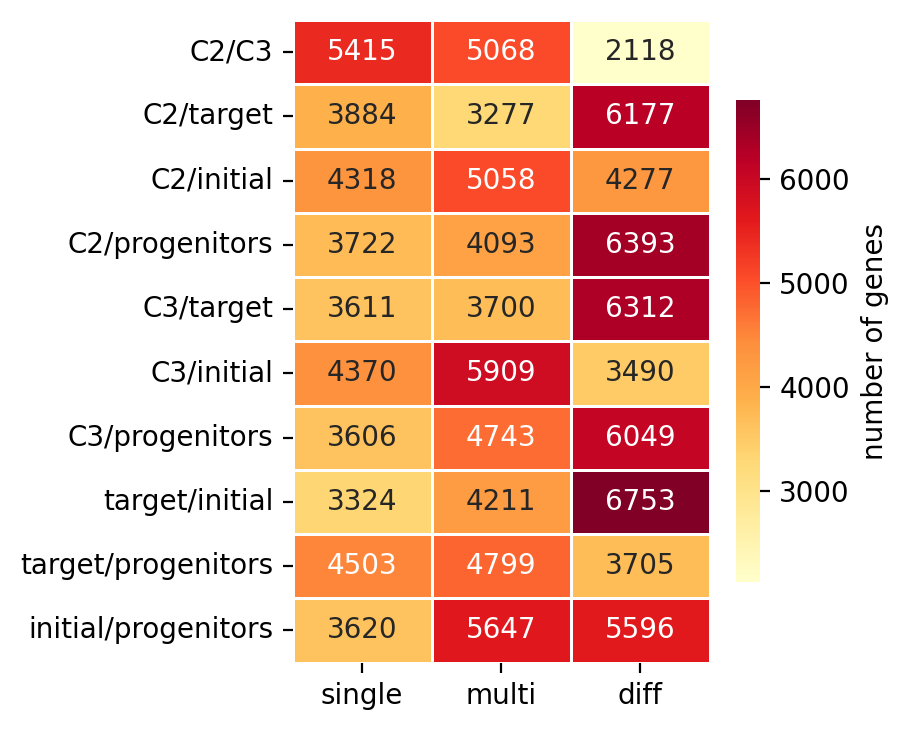

In [69]:

# 1) prepare only-percentage DataFrame
pct_df = (
    summary_df
    .set_index('pair')
    # .filter(regex='_pct$')
)

pct_df.columns = [x.replace("_pct", "") for x in pct_df.columns]
pct_df.index = pct_df.index.str.replace("intial", "initial")
pct_df.index = pct_df.index.str.replace("HSC", "target")

pct_df = pct_df.drop(columns=['NE'])

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4.5, 3.75

sns.heatmap(
    pct_df,
    annot=True,
    fmt='d',
    cbar_kws={'label': 'number of genes', 'shrink' : 0.75, },
    linewidths=0.5,
    cmap='YlOrRd'
)
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [43]:
cols = ['C2', 'C3', 'HSC', 'intial', ]

summary = []
for c1, c2 in combinations(cols, 2):
    # build 3×3 crosstab
    ct = (
        pd.crosstab(results[c1], results[c2])
          .reindex(index=['NE','single','multi'],
                   columns=['NE','single','multi'],
                   fill_value=0)
    )
    total = int(ct.values.sum())
    # diagonal = shared counts
    shared = {t: int(ct.at[t, t]) for t in ct.index}
    different = total - sum(shared.values())
    # compute percentages
    shared_pct = {t: shared[t] / total * 100 for t in shared}
    different_pct = different / total * 100

    summary.append({
        'pair': f'{c1}/{c2}',
        **{f'{t}_pct': round(shared_pct[t], 2) for t in shared_pct},
        'diff_pct': round(different_pct, 2)
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

      pair  NE_pct  single_pct  multi_pct  diff_pct
     C2/C3   56.67       18.62      17.43      7.28
    C2/HSC   54.14       13.36      11.27     21.24
 C2/intial   53.05       14.85      17.39     14.71
    C3/HSC   53.16       12.42      12.72     21.70
 C3/intial   52.65       15.03      20.32     12.00
HSC/intial   50.87       11.43      14.48     23.22


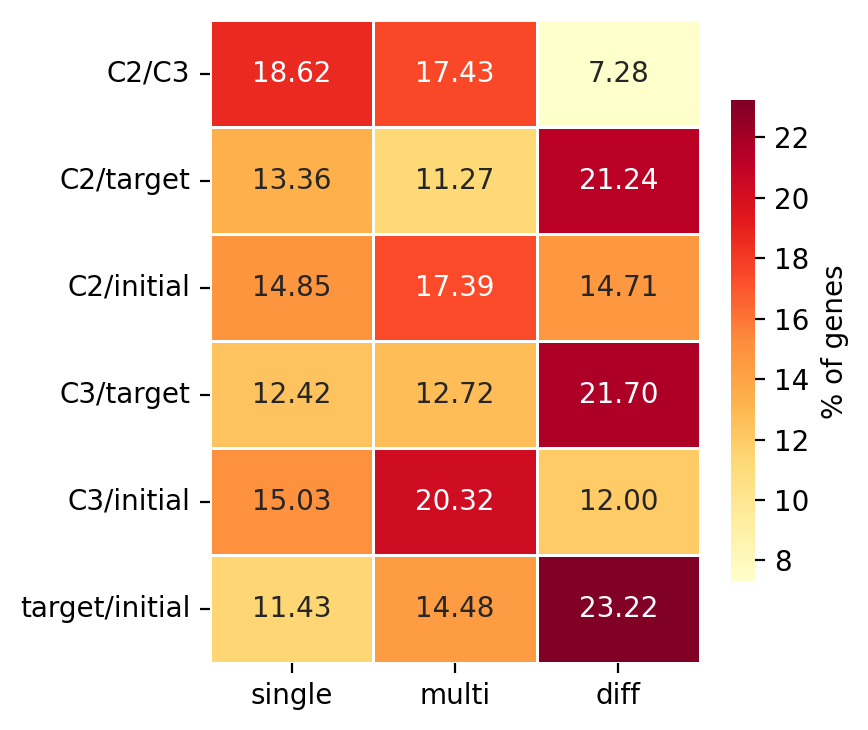

In [63]:

# 1) prepare only-percentage DataFrame
pct_df = (
    summary_df
    .set_index('pair')
    .filter(regex='_pct$')
)

pct_df.columns = [x.replace("_pct", "") for x in pct_df.columns]
pct_df.index = pct_df.index.str.replace("intial", "initial")
pct_df.index = pct_df.index.str.replace("HSC", "target")

pct_df = pct_df.drop(columns=['NE'])

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4.5, 3.75

sns.heatmap(
    pct_df,
    annot=True,
    fmt='.2f',
    cbar_kws={'label': '% of genes', 'shrink' : 0.75, },
    linewidths=0.5,
    cmap='YlOrRd'
)
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

# sankey plot

pdf.shape=(15038, 5)
           intial      C2      C3 progenitors     HSC
gene_name                                            
A2M        single  single  single          NE      NE
A2ML1          NE      NE      NE      single  single
A4GALT      multi   multi   multi          NE      NE
A4GNT      single      NE  single          NE      NE
AAAS        multi   multi   multi       multi  single
AACS       single  single  single      single  single
AADAC          NE  single  single          NE      NE
AADAT       multi  single  single       multi   multi
AAGAB       multi   multi   multi       multi   multi
AAK1        multi   multi   multi      single  single
AAMDC       multi   multi   multi       multi   multi
AAMP        multi   multi   multi       multi   multi
AANAT          NE      NE      NE      single      NE
AAR2        multi  single  single       multi   multi
AARD       single  single      NE      single  single


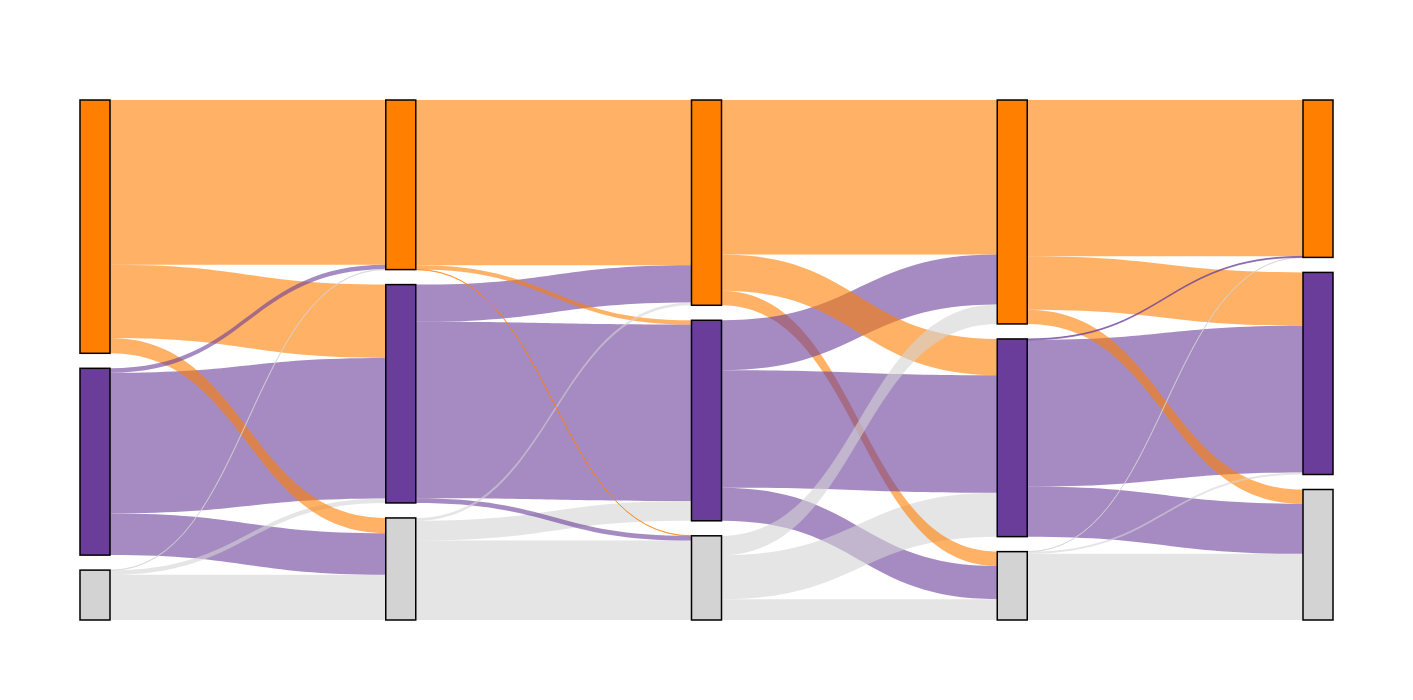

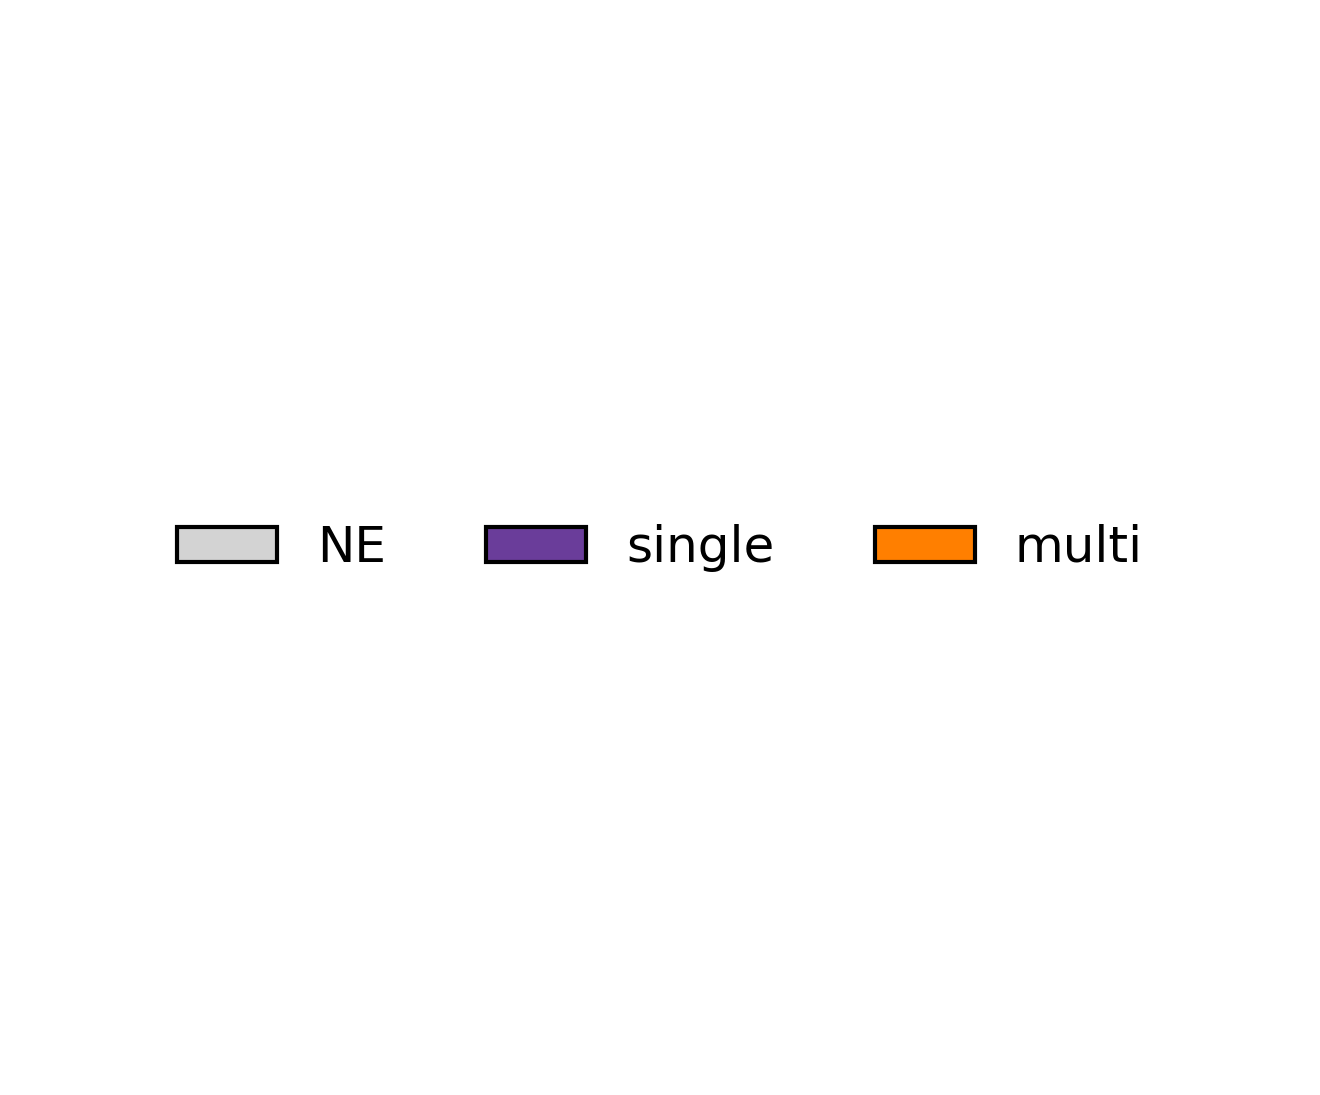

In [58]:
pdf = results.copy()
pdf = pdf.set_index('gene_name')
pdf = pdf[['intial', 'C2', 'C3', 'progenitors', 'HSC']]

# drop rows with all NE
mask = pdf.ne("NE").any(axis=1)
pdf = pdf[mask]
print(f"{pdf.shape=}")
print(pdf.head(15).to_string())

# Flatten transitions: from one stage to the next
stages = pdf.columns.tolist()
labels = ['NE', 'single', 'multi']
label_indices = {label: i for i, label in enumerate(labels)}
colors = {
    "NE" : '#d3d3d3',
    "single": '#6a3d9a',  # purple
    "multi": '#ff7f00',   # orange
}

def hex_to_rgba(hex_color, alpha=0.4):
    from matplotlib.colors import to_rgba
    rgba = to_rgba(hex_color, alpha)
    return f"rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, {rgba[3]:.2f})"


# Desired vertical sort order (top to bottom)
label_order = ['multi', 'single', 'NE']

# Build nodes in consistent stage-wise order
nodes = []
node_lookup = {}
idx = 0
for stage in stages:
    for label in label_order:
        node_name = f"{stage}_{label}"
        nodes.append(node_name)
        node_lookup[node_name] = idx
        idx += 1

source = []
target = []
value = []
link_color = []

for i in range(len(stages) - 1):
    src_stage = stages[i]
    tgt_stage = stages[i + 1]
    
    transitions = pdf[[src_stage, tgt_stage]].values.tolist()
    counts = Counter(tuple(pair) for pair in transitions)
    
    for (src_val, tgt_val), count in counts.items():
        if src_val in labels and tgt_val in labels:
            src_idx = node_lookup[f"{src_stage}_{src_val}"]
            tgt_idx = node_lookup[f"{tgt_stage}_{tgt_val}"]
            source.append(src_idx)
            target.append(tgt_idx)
            value.append(count)
            link_color.append(hex_to_rgba(colors[src_val], alpha=0.6)),

# Sankey plot
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=30,
        line=dict(color="black", width=1.5),
        # label=[node.split('_')[0] for node in nodes],  # Strip stage
        color=[colors[node.split('_')[1]] for node in nodes]
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color=link_color,
    ))])

fig.update_layout(
    font_size=20,
    height=700,
    width=1000,
)
fig.show()


# Create legend handles
legend_elements = [Patch(facecolor=color, edgecolor='k', label=label)
                   for label, color in colors.items()]

# Create figure with only the legend
plt.rcParams['figure.dpi'] = 300
fig, ax = plt.subplots()
ax.axis('off')
legend = ax.legend(
    handles=legend_elements,
    loc='center',
    frameon=False,
    ncols=3,
    fontsize=12,
)
plt.tight_layout()
plt.show()

In [ ]:
%%time
rsc.get.anndata_to_CPU(adata)

tdf = adata.to_df()
print(f"transcript dataframe: {tdf.shape=}")

adata.obs['n_transcripts'] = tdf.astype(bool).sum(axis=1)

tdf.columns = adata.var['gene_name']
tdf = tdf.groupby(level=0, axis=1).sum()
print(f"gene dataframe: {tdf.shape=}")

adata.obs['n_genes'] = tdf.astype(bool).sum(axis=1)

adata.obs.head()

transcript dataframe: tdf.shape=(21062, 113335)


In [ ]:
pdf = adata.obs.copy()
pdf['transcripts_per_gene'] = pdf['n_transcripts'] / pdf['n_genes']


pdf = pdf[~pdf['group'].isin(['bm_other'])]
pdf['group'] = pdf['group'].astype(str)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 2, 3

palette = {
    'intial'  : "#808080",
    'reprogram' : "#CB181D", 
    'target' : "#08306B",
}

sns.boxplot(
    data=pdf,
    x='group',
    y='transcripts_per_gene',
    hue='group',
    showfliers=False,
    width=0.6,
    order=['intial', 'reprogram', 'target'],
    palette=palette,
    linecolor='k',
    capprops={'lw' : 0},
)

plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("transcripts/gene")
sns.despine()

In [ ]:
break

# Summary by subgroup

In [ ]:
transcript_read_threshold = 50
results = []

for group_name, group in adata.obs.groupby('subgroup', observed=True):
    cell_idx = group.index

    tmp = adata[cell_idx, :].copy()
    var = tmp.var.copy()

    var['reads_per_transcript'] = np.ravel(tmp.X.sum(axis=0))
    var['reads_per_gene'] = var.groupby('gene_name')['reads_per_transcript'].transform('sum')
    var['transctipt_pass'] = var['reads_per_transcript'] > transcript_read_threshold
    var['n_isoforms_per_gene'] = var.groupby('gene_name')['transctipt_pass'].transform('sum')

    filtered = var[
        (var['transctipt_pass'] == True) &
        (var['transcript_type'] == 'protein_coding')
    ]

    n_unique_genes = filtered['gene_name'].nunique()
    n_unique_transcripts = filtered['transcript_name'].nunique()


    genes_with_multiple = (
        filtered.groupby('gene_name')['transcript_name']
        .nunique()
        .ge(2)
        .sum()
    )
    
    # summary stats
    row = {
        'subgroup' : group_name,
        'n_unique_genes' : n_unique_genes,
        'n_unique_transcripts' : n_unique_transcripts,
        'genes_with_multiple' : genes_with_multiple,
        'avg_transcripts_per_gene' : n_unique_transcripts / n_unique_genes,
    }

    results.append(row)


results = pd.DataFrame(results)
print(results.to_string(index=False))

In [ ]:
# Variables to plot
metrics = [
    'n_unique_genes',
    'n_unique_transcripts',
    'genes_with_multiple',
    'avg_transcripts_per_gene'
]

# Create a color palette with enough distinct colors
colors = sns.color_palette('tab10', n_colors=len(metrics))

# Plot each metric with a different color
for i, metric in enumerate(metrics):
    plt.rcParams['figure.dpi'] = 200
    plt.rcParams['figure.figsize'] = 4, 3.75
    sns.barplot(
        data=results,
        x='subgroup',
        y=metric,
        ec='k',
        width=0.7,
        color=colors[i],
    )
    plt.title(metric.replace('_', ' '))
    plt.xlabel('')
    plt.ylabel(metric.replace('_', ' '))
    plt.xticks(rotation=90)
    plt.tight_layout()
    sns.despine()
    plt.show()
    # break